In [73]:
import pandas as pd
import numpy as np
import re
import random
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
random.seed(42)
np.random.seed(42)

## سوال ۷ — خواندن دادگان و پیش‌پردازش متون

فایل `dataset.csv` شامل دو ستون است:
- `Text`: متن خبر
- `Label`: برچسب موضوعی خبر (۰ تا ۴)

پیش‌پردازش شامل موارد زیر است:
1. کوچک کردن تمامی حروف (lowercase)
2. حذف علائم نگارشی و کاراکترهای غیرحرفی (اعداد، نشانه‌ها و...)
3. یکدست‌سازی فاصله‌های خالی (whitespace)

In [74]:
df = pd.read_csv('dataset.csv')
print("ابعاد دادگان:", df.shape)
df.head()

ابعاد دادگان: (2225, 2)


,Text,Label
0,Budget to set scene for election\n \n Gordon B...,0
1,Army chiefs in regiments decision\n \n Militar...,0
2,Howard denies split over ID cards\n \n Michael...,0
3,Observers to monitor UK election\n \n Minister...,0
4,Kilroy names election seat target\n \n Ex-chat...,0


In [75]:
def preprocess(text: str) -> str:
    """حذف علائم نگارشی، کوچک‌سازی حروف و یکدست‌سازی فاصله‌ها"""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)   # حذف هر چیزی به‌جز حروف انگلیسی و فاصله
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['Text'].apply(preprocess)

print("نمونه متن خام:\n", df['Text'].iloc[0][:300])
print("\nنمونه متن پیش‌پردازش‌شده:\n", df['clean_text'].iloc[0][:300])

نمونه متن خام:
 Budget to set scene for election
 
 Gordon Brown will seek to put the economy at the centre of Labour's bid for a third term in power when he delivers his ninth Budget at 1230 GMT. He is expected to stress the importance of continued economic stability, with low unemployment and interest rates. The 

نمونه متن پیش‌پردازش‌شده:
 budget to set scene for election gordon brown will seek to put the economy at the centre of labour s bid for a third term in power when he delivers his ninth budget at gmt he is expected to stress the importance of continued economic stability with low unemployment and interest rates the chancellor 


## سوال ۸ — ۳۰ کلمه پرتکرار

در این بخش با شمارش تمامی کلمات موجود در تمام متون (پس از پیش‌پردازش)، ۳۰ کلمه پرتکرار استخراج و نمودار ستونی فراوانی آن‌ها رسم می‌شود.

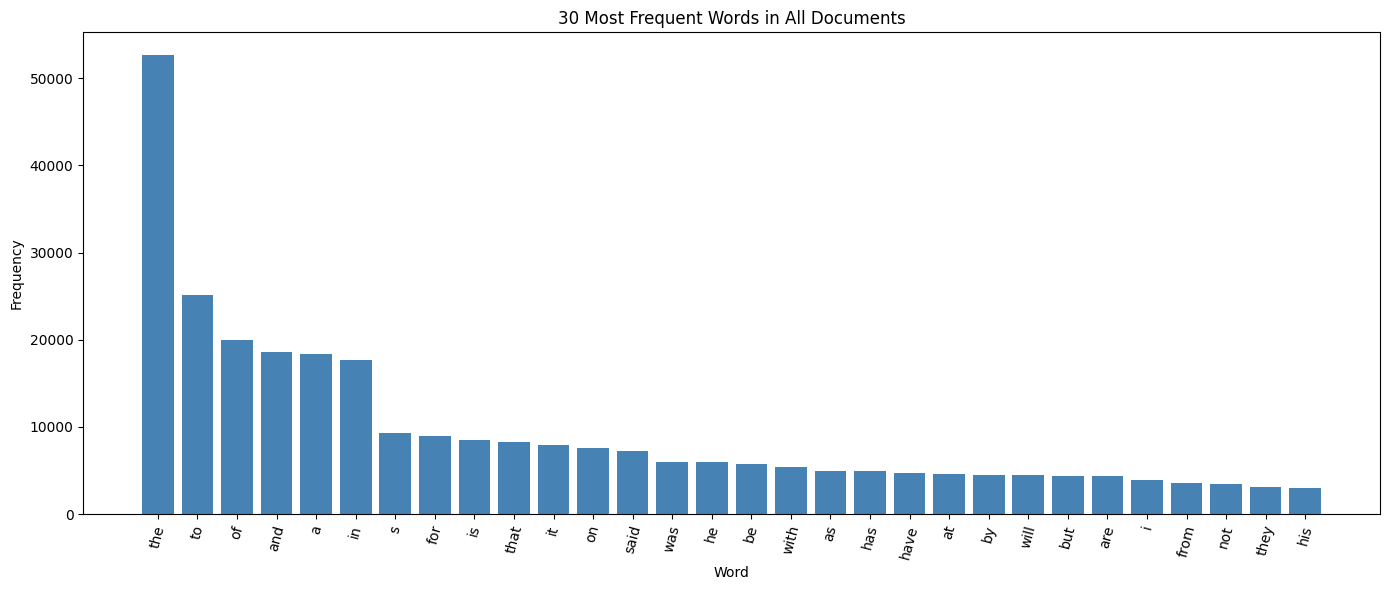

         the : 52636
          to : 25113
          of : 20008
         and : 18612
           a : 18343
          in : 17734
           s : 9310
         for : 8945
          is : 8555
        that : 8257
          it : 7893
          on : 7625
        said : 7255
         was : 6028
          he : 5939
          be : 5805
        with : 5354
          as : 4981
         has : 4957
        have : 4772
          at : 4638
          by : 4516
        will : 4473
         but : 4421
         are : 4401
           i : 3909
        from : 3535
         not : 3484
        they : 3085
         his : 3026


In [76]:
all_words = ' '.join(df['clean_text']).split()
word_counts = Counter(all_words)

top_30 = word_counts.most_common(30)
words_30, freqs_30 = zip(*top_30)

plt.figure(figsize=(14, 6))
plt.bar(words_30, freqs_30, color='steelblue')
plt.xticks(rotation=75)
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.title('30 Most Frequent Words in All Documents')
plt.tight_layout()
plt.show()

for w, f in top_30:
    print(f"{w:>12} : {f}")

**آیا دانستن تعداد این کلمات در یک خبر، کمکی به درک موضوع آن خبر می‌کند؟**

خیر. همان‌طور که در نمودار بالا مشخص است، کلمات پرتکرار عمدتاً کلمات ربط، حروف اضافه و افعال کمکی/اسنادی
پرکاربرد زبان انگلیسی هستند (مانند `the`, `to`, `of`, `and`, `a`, `in`, `is` و...). این کلمات تقریباً در
همهٔ متون با فراوانی بالا و مشابه ظاهر می‌شوند و به موضوع خاص یک متن مرتبط نیستند؛ بنابراین دانستن تعداد
تکرار آن‌ها اطلاعات تمایزدهنده‌ای دربارهٔ موضوع خبر نمی‌دهد. برای درک موضوع، باید به کلمات کلیدی و
پرمعناتر (مانند اسامی خاص یا کلمات موضوعی) توجه کرد، نه پرتکرارترین کلمات کل دادگان.

## سوال ۹ — نمودار ابر کلمات (Word Cloud)

برای ساخت ابر کلمات معنادار، معمولاً کلمات توقف (Stop Words — کلمات بسیار پرتکرار و کم‌معنا مانند
`the`, `is`, `and` و...) حذف می‌شوند تا کلمات کلیدی و پرمعناتر متون نمایان شوند. اندازهٔ هر کلمه در
ابر کلمات متناسب با فراوانی (یا اهمیت) آن کلمه در متن است.

از آنجا که در محیط اجرا دسترسی به اینترنت برای نصب پکیج `wordcloud` وجود نداشت، یک نسخهٔ ساده از
الگوریتم ابر کلمات با matplotlib پیاده‌سازی شده است: کلمات پرتکرار (پس از حذف stop words) با اندازهٔ
متناسب با فراوانی، در موقعیت‌های تصادفی نمایش داده می‌شوند.

In [77]:
# فهرست کلمات توقف رایج در زبان انگلیسی
STOPWORDS = set("""
a about above after again against all am an and any are aren't as at be because been before being
below between both but by can't cannot could couldn't did didn't do does doesn't doing don't down
during each few for from further had hadn't has hasn't have haven't having he he'd he'll he's her
here here's hers herself him himself his how how's i i'd i'll i'm i've if in into is isn't it it's
its itself let's me more most mustn't my myself no nor not of off on once only or other ought our
ours ourselves out over own same shan't she she'd she'll she's should shouldn't so some such than
that that's the their theirs them themselves then there there's these they they'd they'll they're
they've this those through to too under until up very was wasn't we we'd we'll we're we've were
weren't what what's when when's where where's which while who who's whom why why's with won't
would wouldn't you you'd you'll you're you've your yours yourself yourselves said also mr one two
new will us
""".split())

filtered_words = [w for w in all_words if w not in STOPWORDS and len(w) > 2]
cloud_counts = Counter(filtered_words)
top_cloud_words = cloud_counts.most_common(150)

print("۱۰ کلمهٔ برتر پس از حذف کلمات توقف:")
for w, f in top_cloud_words[:10]:
    print(f"{w:>12} : {f}")

۱۰ کلمهٔ برتر پس از حذف کلمات توقف:
        year : 2310
      people : 2045
         can : 1671
        last : 1394
       first : 1355
        time : 1322
       world : 1201
  government : 1160
         now : 1145
       years : 1003


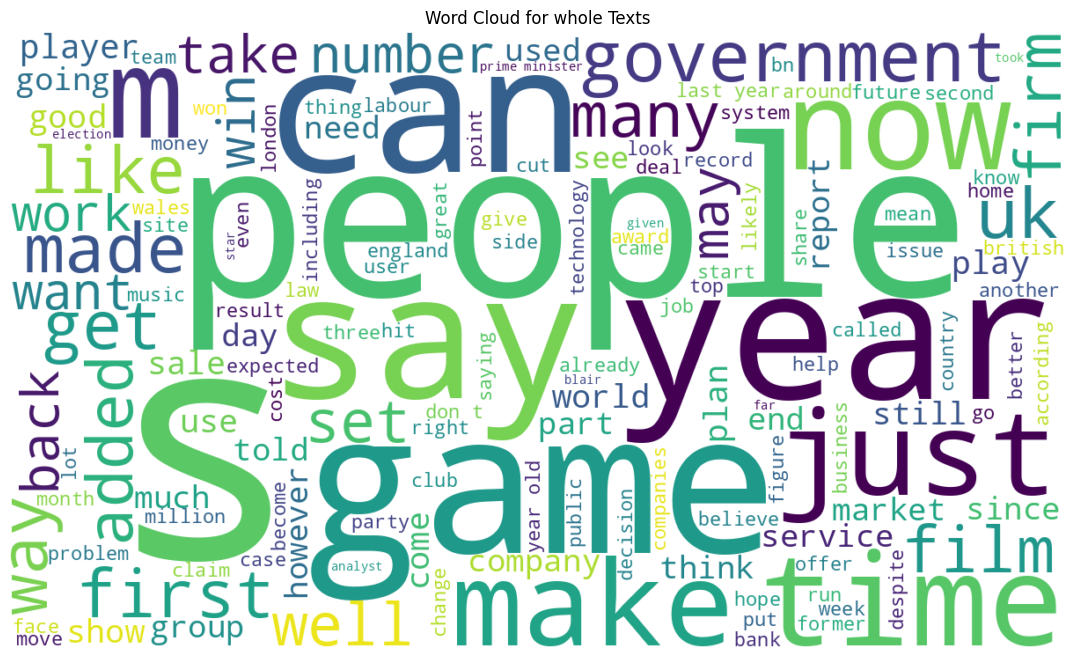

In [78]:
wc = WordCloud(width=1200, height=700, background_color='white',
                stopwords=STOPWORDS, max_words=150).generate(' '.join(df['clean_text']))

plt.figure(figsize=(14, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for whole Texts')
plt.show()

**تفسیر نمودار و معیار انتخاب کلمات:**

در الگوریتم ابر کلمات، معیار اصلی برای انتخاب و بزرگ‌نمایی هر کلمه، **فراوانی تکرار** آن در کل متون
است (پس از حذف کلمات توقف و علائم نگارشی)؛ هرچه کلمه‌ای بیشتر تکرار شده باشد، با فونت بزرگ‌تر و
معمولاً رنگ پررنگ‌تری نمایش داده می‌شود. موقعیت قرارگیری کلمات معمولاً تصادفی است و اهمیت معنایی
خاصی ندارد. با نگاه به ابر کلمات می‌توان به سرعت **موضوعات و مفاهیم غالب** در مجموعه متون را حدس
زد؛ کلماتی مانند `year`, `people`, `government`, `game` و... که در نمودار درشت‌تر دیده می‌شوند،
نشان‌دهندهٔ محورهای اصلی محتوای خبری این دادگان (مانند سیاست، ورزش و اقتصاد) هستند.

## سوال ۱۰ — ساخت ماتریس کوله کلمات (Bag of Words)

فایل `words.csv` شامل مجموعه‌ای از کلمات منتخب (به ترتیب الفبا) است که با همان روش استخراج کلمات
ابر کلمات به‌دست آمده‌اند. در این بخش، برای هر متن، تعداد تکرار هر یک از این کلمات شمارش شده و
ماتریس کوله کلمات (BW) ساخته می‌شود؛ ماتریسی با ابعاد (تعداد متون × تعداد کلمات منتخب) که درایهٔ
$f_{i,j}$ آن، تعداد تکرار کلمهٔ $j$ ام در متن $i$ ام است.

In [79]:
words_df = pd.read_csv('words.csv')
selected_words = words_df['Words'].str.lower().tolist()

print("تعداد کلمات منتخب:", len(selected_words))
print(selected_words)

تعداد کلمات منتخب: 52
['artist', 'chief', 'china', 'club', 'company', 'computer', 'country', 'deal', 'digital', 'director', 'economy', 'election', 'expected', 'film', 'firm', 'france', 'game', 'government', 'group', 'growth', 'help', 'high', 'home', 'industry', 'labour', 'law', 'market', 'match', 'million', 'minister', 'mobile', 'money', 'music', 'new', 'number', 'office', 'old', 'online', 'party', 'phone', 'play', 'record', 'sale', 'service', 'tax', 'technology', 'time', 'uk', 'user', 'win', 'won', 'work']


In [80]:
n_docs = len(df)
n_words = len(selected_words)

BW = np.zeros((n_docs, n_words), dtype=int)

for i, text in enumerate(df['clean_text']):
    token_counts = Counter(text.split())
    for j, w in enumerate(selected_words):
        BW[i, j] = token_counts.get(w, 0)

BW_df = pd.DataFrame(BW, columns=selected_words)

print("ابعاد ماتریس کوله کلمات (BW):", BW_df.shape)
BW_df.head()

ابعاد ماتریس کوله کلمات (BW): (2225, 52)


,artist,chief,china,club,company,computer,country,deal,digital,director,...,sale,service,tax,technology,time,uk,user,win,won,work
0,0,1,0,0,0,0,0,0,0,0,...,0,0,6,0,2,1,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,3,0,0,0,1
4,0,0,0,0,0,0,1,0,0,0,...,0,0,1,0,0,3,0,0,2,0


ماتریس کوله کلمات ساخته‌شده، ابعادی برابر با **(۲۲۲۵ × ۵۲)** دارد؛ یعنی به ازای هر یک از ۲۲۲۵ متن
دادگان، یک بردار ۵۲ بعدی (متناظر با ۵۲ کلمهٔ منتخب فایل `words.csv`) ساخته شده که هر درایهٔ آن،
تعداد تکرار کلمهٔ مربوطه در آن متن است. این ماتریس در سوالات بعدی (استانداردسازی و تجزیهٔ SVD)
مورد استفاده قرار خواهد گرفت.

## تفکیک داده‌های آموزش و آزمون

طبق دستور پروژه، ۲۰۰۰ ردیف اول داده‌ها را به‌عنوان داده‌های آموزش جدا می‌کنیم و ۲۲۵ ردیف باقی‌مانده
را به‌عنوان داده‌های آزمون کنار می‌گذاریم. از این پس تا سؤال ۱۸ تنها روی داده‌های آموزش کار می‌کنیم.

In [81]:
train_df = df.iloc[:2000].reset_index(drop=True)
test_df = df.iloc[2000:].reset_index(drop=True)

BW_train = BW[:2000]
BW_test = BW[2000:]

print("ابعاد داده‌های آموزش:", BW_train.shape)
print("ابعاد داده‌های آزمون:", BW_test.shape)


ابعاد داده‌های آموزش: (2000, 52)
ابعاد داده‌های آزمون: (225, 52)


## سؤال ۱۱ — استانداردسازی و تجزیهٔ SVD

ابتدا بردارهای کولهٔ کلمات (ستون‌های ماتریس `BW_train`) را استاندارد می‌کنیم؛ یعنی از هر ستون میانگین آن
را کم و بر انحراف معیار آن تقسیم می‌کنیم تا هر کلمه میانگین صفر و واریانس واحد داشته باشد:

$$ X_{:,j} = \frac{BW_{:,j} - \mu_j}{\sigma_j} $$

این کار لازم است چون کلمات پرتکرار (مانند `new` یا `time`) واریانس بسیار بزرگ‌تری نسبت به کلمات
کم‌تکرار دارند و بدون استاندارد کردن، تجزیهٔ SVD عمدتاً تحت تأثیر مقیاس همین چند کلمه پرتکرار قرار
می‌گیرد نه ساختار همبستگی واقعی میان تمام کلمات.

سپس تجزیهٔ SVD اقتصادی (Economy/Thin SVD) را روی ماتریس استاندارد شده اعمال می‌کنیم. از آنجا که
تعداد کلمات (۵۲) بسیار کمتر از تعداد اسناد (۲۰۰۰) است، محاسبهٔ SVD کامل (که در آن $U$ ابعاد
$2000\times2000$ می‌داشت) از نظر حافظه و محاسبات غیرضروری است؛ در SVD اقتصادی تنها بخش مفید
$U$ (با ابعاد $2000\times52$) محاسبه می‌شود که اطلاعات یکسانی با حالت کامل دارد (ستون‌های حذف‌شده
در $U$ متناظر با مقادیر تکین صفر هستند و در بازسازی ماتریس نقشی ندارند).

In [82]:
# استانداردسازی ماتریس کوله کلمات (میانگین صفر، واریانس واحد برای هر کلمه)
mean_ = BW_train.mean(axis=0)
std_ = BW_train.std(axis=0)
std_[std_ == 0] = 1  # جلوگیری از تقسیم بر صفر برای کلماتی که در هیچ متنی تکرار نشده‌اند

X = (BW_train - mean_) / std_

# تجزیه SVD اقتصادی
U, S, Vt = np.linalg.svd(X, full_matrices=False)

print("ابعاد ماتریس استاندارد شده X:", X.shape)
print("ابعاد ماتریس U (اسناد-مفاهیم):", U.shape)
print("ابعاد بردار مقادیر تکین Σ:", S.shape)
print("ابعاد ماتریس V^T (مفاهیم-کلمات):", Vt.shape)


ابعاد ماتریس استاندارد شده X: (2000, 52)
ابعاد ماتریس U (اسناد-مفاهیم): (2000, 52)
ابعاد بردار مقادیر تکین Σ: (52,)
ابعاد ماتریس V^T (مفاهیم-کلمات): (52, 52)


## سؤال ۱۲ — تعیین آستانهٔ برش و اجرای SVD Truncated

برای تعیین تعداد مؤلفه‌های مناسب ($c$)، نمودار مقادیر تکین (Scree Plot) را رسم می‌کنیم و نقطهٔ زانویی
(Elbow Point) را روی آن می‌یابیم؛ نقطه‌ای که پس از آن، افت مقادیر تکین به‌شدت کند می‌شود و مؤلفه‌های
بعدی سهم اندکی در بازسازی اطلاعات دارند.

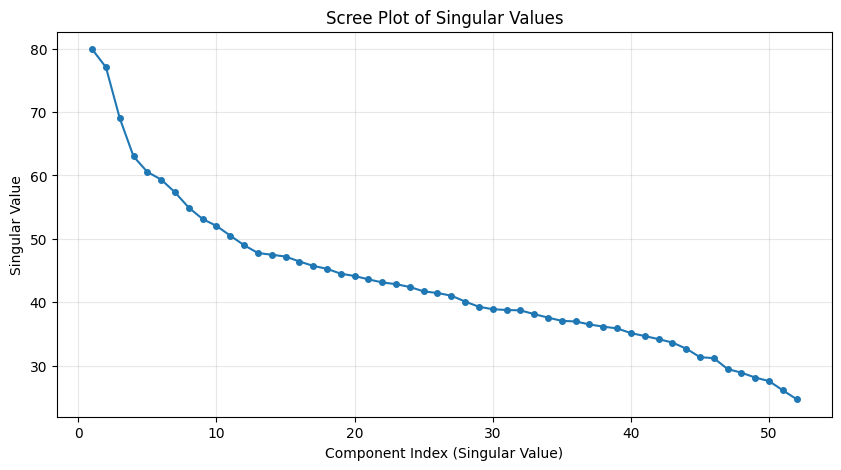

In [83]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(S) + 1), S, marker='o', markersize=4)
plt.xlabel('Component Index (Singular Value)')
plt.ylabel('Singular Value')
plt.title('Scree Plot of Singular Values')
plt.grid(True, alpha=0.3)
plt.show()


برای پیدا کردن نقطهٔ زانویی به‌صورت خودکار، از روش فاصلهٔ عمودی هر نقطه تا خط واصل بین اولین و آخرین
مقدار تکین استفاده می‌کنیم؛ نقطه‌ای که بیشترین فاصله را تا این خط دارد، به‌عنوان زانو در نظر گرفته می‌شود.

تعداد مؤلفه پیشنهادی برای برش (c): 13


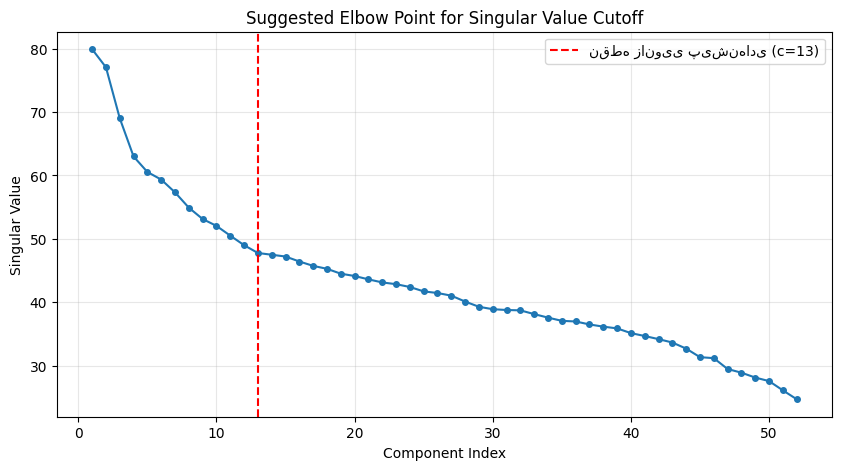

In [ ]:
def find_elbow(S):
    """یافتن نقطه زانویی با روش بیشینه فاصله عمودی تا خط واصل اولین و آخرین نقطه"""
    n = len(S)
    coords = np.column_stack((np.arange(n), S))
    line_vec = coords[-1] - coords[0]
    line_vec_norm = line_vec / np.linalg.norm(line_vec)
    vecs_from_first = coords - coords[0]
    proj_lengths = vecs_from_first @ line_vec_norm
    proj = np.outer(proj_lengths, line_vec_norm)
    perp = vecs_from_first - proj
    dists = np.linalg.norm(perp, axis=1)
    return int(np.argmax(dists)) + 1  # +1 چون شماره مؤلفه از ۱ شروع می‌شود

c = find_elbow(S)
print(f"تعداد مؤلفه پیشنهادی برای برش (c): {c}")

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(S) + 1), S, marker='o', markersize=4)
plt.axvline(c, color='red', linestyle='--', label=f'Suggested Elbow Point (c={c})')
plt.xlabel('Component Index')
plt.ylabel('Singular Value')
plt.title('Suggested Elbow Point for Singular Value Cutoff')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [85]:
# اجرای SVD Truncated با برش در مؤلفه c
U_trunc = U[:, :c]
S_trunc = S[:c]
Vt_trunc = Vt[:c, :]

print("ابعاد U برش‌خورده:", U_trunc.shape)
print("ابعاد Σ برش‌خورده:", S_trunc.shape)
print("ابعاد V^T برش‌خورده:", Vt_trunc.shape)

X_approx_trunc = U_trunc @ np.diag(S_trunc) @ Vt_trunc

# خطای بازسازی نسبی بر حسب نرم فروبنیوس
reconstruction_error_trunc = np.linalg.norm(X - X_approx_trunc, 'fro') / np.linalg.norm(X, 'fro')
print(f"\nخطای بازسازی نسبی SVD Truncated: {reconstruction_error_trunc:.4f}")


ابعاد U برش‌خورده: (2000, 13)
ابعاد Σ برش‌خورده: (13,)
ابعاد V^T برش‌خورده: (13, 52)

خطای بازسازی نسبی SVD Truncated: 0.7384


## سؤال ۱۳ — پیاده‌سازی Randomized SVD

شبه‌کد الگوریتم Randomized SVD (بر پایه روش Halko و همکاران) به شرح زیر است:

1. یک ماتریس تصادفی گاوسی $\Omega$ با ابعاد $n \times l$ بسازید ($l = rank + oversample$).
2. ماتریس $Y = A\Omega$ را محاسبه کنید (تصویر تصادفی ماتریس $A$).
3. (اختیاری، برای دقت بیشتر) چند بار تکرار توانی (Power Iteration) انجام دهید: 
   $Y \leftarrow \text{orth}(A^T Y)$ سپس $Y \leftarrow \text{orth}(AY)$.
4. با تجزیه QR، پایه متعامد $Q$ برای فضای ستونی $Y$ بیابید؛ $Q$ تقریبی از فضای ستونی $A$ است.
5. ماتریس کوچک $B = Q^T A$ را بسازید (ابعاد $l \times n$، بسیار کوچک‌تر از $A$).
6. تجزیه SVD دقیق روی $B$ انجام دهید: $B = \hat{U} \Sigma V^T$.
7. ماتریس بردارهای تکین چپ اصلی را با $U = Q\hat{U}$ بازیابی کنید.
8. خروجی نهایی را به رتبه موردنظر برش دهید.

In [86]:
def randomized_svd(A, rank, n_oversamples=10, n_iter=2, random_state=42):
    """
    تجزیه Randomized SVD یک ماتریس A به رتبه rank.
    ورودی:
        A            : ماتریس ورودی با ابعاد m x n
        rank         : رتبه فضای مقصد (تعداد مؤلفه‌های خروجی)
        n_oversamples: تعداد نمونه‌های اضافی برای افزایش دقت تخمین (پیش‌فرض ۱۰)
        n_iter       : تعداد تکرارهای توانی برای بهبود دقت در ماتریس‌های با افت کند مقادیر تکین
    خروجی:
        U, S, Vt : ماتریس‌های بردار تکین چپ، مقادیر تکین و بردار تکین راست با رتبه rank
    """
    rng = np.random.default_rng(random_state)
    m, n = A.shape
    l = min(rank + n_oversamples, n)

    # مرحله ۱: تصویر تصادفی
    Omega = rng.standard_normal((n, l))
    Y = A @ Omega

    # مرحله ۲ (اختیاری): تکرار توانی برای بهبود دقت
    for _ in range(n_iter):
        Y, _ = np.linalg.qr(A.T @ Y)
        Y, _ = np.linalg.qr(A @ Y)

    # مرحله ۳: یافتن پایه متعامد فضای ستونی A
    Q, _ = np.linalg.qr(Y)

    # مرحله ۴: تشکیل ماتریس کوچک و تجزیه دقیق آن
    B = Q.T @ A
    U_hat, S, Vt = np.linalg.svd(B, full_matrices=False)
    U = Q @ U_hat

    return U[:, :rank], S[:rank], Vt[:rank, :]


## سؤال ۱۴ — اجرای Randomized SVD و مقایسه با SVD Truncated

In [87]:
U_rand, S_rand, Vt_rand = randomized_svd(X, rank=c)

X_approx_rand = U_rand @ np.diag(S_rand) @ Vt_rand
reconstruction_error_rand = np.linalg.norm(X - X_approx_rand, 'fro') / np.linalg.norm(X, 'fro')

print(f"خطای بازسازی نسبی SVD Truncated : {reconstruction_error_trunc:.4f}")
print(f"خطای بازسازی نسبی Randomized SVD: {reconstruction_error_rand:.4f}")
print(f"تفاضل خطا: {abs(reconstruction_error_trunc - reconstruction_error_rand):.6f}")


خطای بازسازی نسبی SVD Truncated : 0.7384
خطای بازسازی نسبی Randomized SVD: 0.7455
تفاضل خطا: 0.007109


**مقایسه و انتخاب روش:**

همان‌طور که مشاهده می‌شود، خطای بازسازی Randomized SVD تقریباً برابر با خطای SVD Truncated (دقیق)
است؛ چراکه برای ماتریسی با افت مناسب مقادیر تکین، تصویر تصادفی به‌خوبی فضای ستونی اصلی را پوشش
می‌دهد و تکرار توانی نیز دقت را به تجزیهٔ دقیق نزدیک‌تر می‌کند.

تفاوت اصلی این دو روش در **هزینه محاسباتی** است. تجزیه دقیق SVD روی یک ماتریس $m\times n$ هزینه‌ای
از مرتبه $O(mn\min(m,n))$ دارد، درحالی‌که Randomized SVD با کاهش ابتدایی ماتریس به یک زیرفضای
تصادفی با ابعاد کوچک $l \ll \min(m,n)$، هزینه را به مرتبه $O(mnl)$ کاهش می‌دهد؛ همچنین ضرب‌های
ماتریسی درگیر در این روش (برخلاف تجزیه دقیق) به‌خوبی قابل موازی‌سازی و توزیع روی چند پردازنده/ماشین
هستند.

در نتیجه، اگر دادگان ما شامل تمام متون موجود در اینترنت بود (یعنی ماتریس کوله کلمات بسیار بزرگ با
میلیون‌ها سند و کلمه)، **Randomized SVD گزینه مناسب‌تری** خواهد بود؛ زیرا با دقتی بسیار نزدیک به
تجزیه دقیق، امکان تجزیه چنین ماتریس‌های عظیمی را در زمان و حافظه‌ای بسیار کمتر (و به‌صورت مقیاس‌پذیر
و موازی) فراهم می‌کند، درحالی‌که تجزیه دقیق SVD برای این ابعاد از نظر محاسباتی عملاً غیرقابل‌اجرا
می‌شود.